In [ ]:
# !pip install linearmodels

# Pendahuluan

1. Tujuan:
* Mencari faktor apa saja yang menjadi penentu capital structure perusahaan properti di Indonesia

2. Hipotesis:
* H0 = Tidak ada pengaruh variabel X terhadap Y
* H1 = Terdapat pengaruh variabel X terhadap Y

3. Variabel X (independen) dan Y (dependen)
* Variabel X = Profitabilitas atau Retorn on Equity (ROE), Struktur Aset Fisik atau Tangibility (TAN), Likuiditas (LIQ), Pertumbuhan Perusahaan (GRW), Ukuran Perusahaan atau Size (SIZ), Beban Pajak (TAX), Umur Perusahaan (AGE), Penghematan Pajak Selain Utang atau Non-Debt Tax Shield (NDTS)
* Variabel Y = Debt-to-Eqiuty (DER), Total Debt Ratio (TDR)

4. Referensi Utama:

> Masih Coming Soon dalam proses publikasi. Namun topiknya adalah *"Determinan of Capital Structure dari Perusahaan Properti"*

5. Dataset
* Data didapatkan secara primer dengan menghubungi Author secara langsung

# Import dan Load

In [2]:
# Library olah data default
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams

# Analisis Panel
import scipy.stats as stats
import statsmodels.api as sm
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, lilliefors
from statsmodels.stats.stattools import durbin_watson

# Eskport
import joblib

In [3]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [4]:
df_property = pd.read_excel('https://drive.google.com/uc?id=1jk8SfEEmw80GQCA-2TekI8zmX0tjPK4J', sheet_name='HASIL PERHITUNGAN')

In [5]:
print(df_property.groupby('Tahun')['Emiten'].count())

Tahun
2020    40
2021    40
2022    40
2023    40
2024    40
Name: Emiten, dtype: int64


In [6]:
df_property = df_property.set_index(['Emiten', 'Tahun']).sort_index()

In [7]:
df_property.head(10)

DER       TDR       ROE       TAN       LIQ       GRW  \
Emiten Tahun                                                               
APLN   2020   1.676421  0.626367  0.015864  0.615793  1.895883  0.306884   
       2021   1.809463  0.644060 -0.046038  0.596135  1.634991 -0.141250   
       2022   1.295011  0.564272  0.181956  0.605022  1.958465  1.035556   
       2023   1.105918  0.525148  0.086572  0.607771  1.301291 -0.460209   
       2024   0.894971  0.472287  0.055901  0.584041  2.433227  0.192468   
ASRI   2020   1.261504  0.557816 -0.110441  0.898430  0.674138 -0.593388   
       2021   1.300101  0.565237  0.014988  0.861657  0.835173  1.014732   
       2022   1.095247  0.522729  0.103204  0.836935  0.978071  0.578160   
       2023   0.972839  0.493116  0.056573  0.869344  0.787737 -0.119620   
       2024   0.942443  0.485184  0.005746  0.871374  0.764560 -0.132122   

                    SIZ       TAX       AGE      NDTS  
Emiten Tahun                                           
APLN   2020   31.045179  0.171031  2.302585  0.006210  
       2021   31.019171  0.330957  2.397895  0.009656  
       2022   30.985049  0.083012  2.484907  0.008786  
       2023   30.974856  0.212327  2.564949  0.008564  
       2024   30.893710  0.144194  2.639057  0.007938  
ASRI   2020   30.686286  0.656215  2.564949  0.004944  
       2021   30.719058  0.078513  2.639057  0.002850  
       2022   30.735560  0.057735  2.708050  0.002754  
       2023   30.732744  0.077696  2.772589  0.002225  
       2024   30.722928  0.084770  2.833213  0.002450

# Statistik Deskriptif

In [8]:
df_property.shape

(200, 10)

In [9]:
df_property.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 200 entries, ('APLN', np.int64(2020)) to ('TARA', np.int64(2024))
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DER     200 non-null    float64
 1   TDR     200 non-null    float64
 2   ROE     200 non-null    float64
 3   TAN     200 non-null    float64
 4   LIQ     200 non-null    float64
 5   GRW     200 non-null    float64
 6   SIZ     200 non-null    float64
 7   TAX     200 non-null    float64
 8   AGE     200 non-null    float64
 9   NDTS    200 non-null    float64
dtypes: float64(10)
memory usage: 17.7+ KB


In [10]:
df_property.describe()

,DER,TDR,ROE,TAN,LIQ,GRW,SIZ,TAX,AGE,NDTS
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.808567,0.367834,-0.010237,0.637327,2.726788,0.161625,29.224868,0.096047,2.903403,0.006413
std,0.889709,0.192146,0.322337,0.215583,2.698986,0.921038,1.607493,0.402402,0.579803,0.008543
min,0.019447,0.019076,-4.179604,0.146985,0.100481,-0.942953,24.622683,-1.839101,0.693147,0.000002
25%,0.319440,0.242102,-0.034656,0.499187,1.255933,-0.170656,28.105418,-0.017342,2.564949,0.001410
50%,0.575584,0.365315,0.017416,0.611903,2.080250,0.044008,29.537737,0.099447,3.178054,0.003041
75%,0.987777,0.496924,0.069232,0.820012,3.159556,0.231387,30.350714,0.170012,3.340977,0.007035
max,7.306101,0.879607,0.610166,0.989390,23.663231,7.758351,31.962062,3.837498,3.555348,0.041012


In [11]:
Y1_var = ['DER']
Y2_var = ['TDR']
X_var = list(df_property.columns[2:])
print(X_var)

['ROE', 'TAN', 'LIQ', 'GRW', 'SIZ', 'TAX', 'AGE', 'NDTS']


# Eksplorasi Visualisasi Korelasi

**Within-Entity Correlation**: Bagaimana perubahan dalam satu emiten setiap tahun

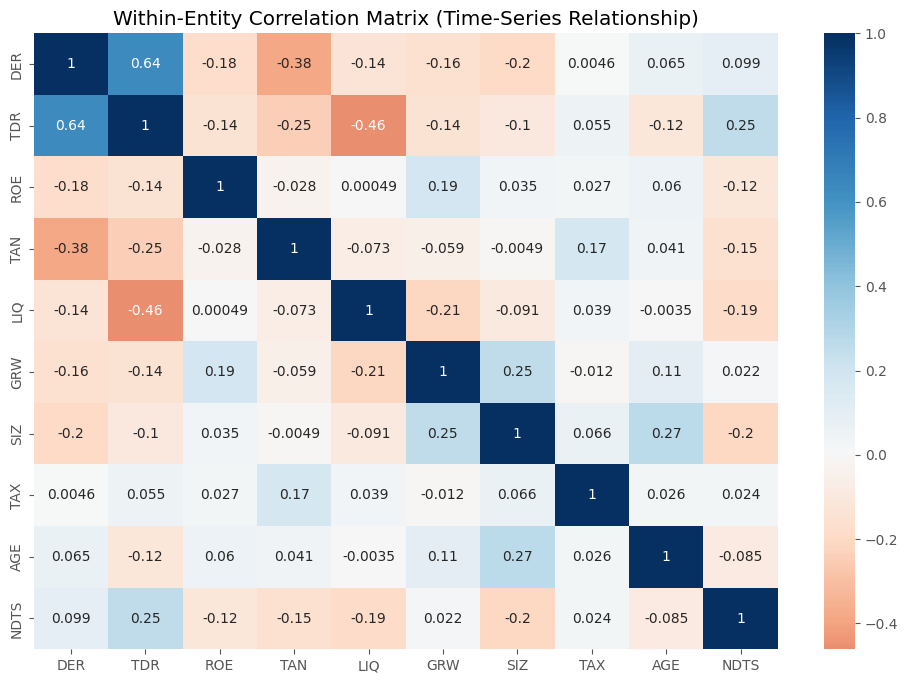

In [12]:
df_within = df_property.groupby('Emiten')[df_property.columns].transform(lambda x: x - x.mean())

plt.figure(figsize=(12, 8))
sns.heatmap(df_within.corr(), annot=True, cmap='RdBu', center=0)
plt.title("Within-Entity Correlation Matrix (Time-Series Relationship)")
plt.show()

**Between-Entity Correlation**: Bagaimana perbedaan antara satu Emiten dengan lainnya?

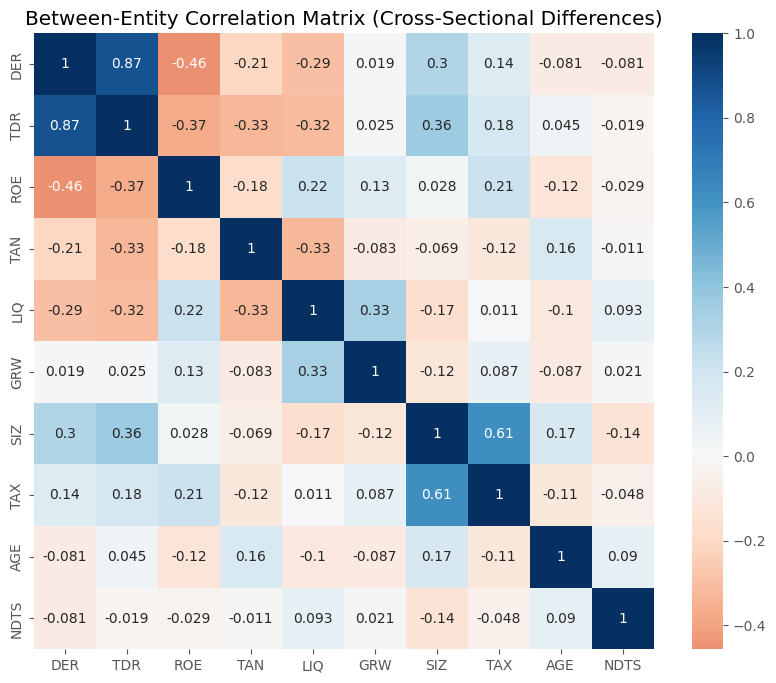

In [13]:
# 2. Collapse the panel into a cross-section (the 'Between' data)
df_between = df_property.groupby('Emiten')[df_property.columns].mean()

# 3. Calculate Correlation
between_corr = df_between.corr()

# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(between_corr, annot=True, cmap='RdBu', center=0)
plt.title("Between-Entity Correlation Matrix (Cross-Sectional Differences)")
plt.show()

# Pemilihan Model (Uji Spesifikasi)

Dengan urutan seperti ini:
1. **Tahap 1** : Uji Chow. Jika p-value < 0.05, maka lanjut ke Tahap 2. Jika p-value > 0.05, maka lanjut ke Tahap 3
2. **Tahap 2** : Uji Hausman. Jika p-value < 0.05, maka pilih FEM. Jika p-value > 0.05, maka pilih REM
3. **Tahap 3** : Uji Lagrange Multiplier. Jika p-value < 0.05, maka pilih REM . Jika p-value > 0.05, maka pilih CEM

In [14]:
Y1 = df_property[Y1_var]
Y2 = df_property[Y2_var]
X = df_property[X_var]
X_sm = sm.add_constant(X)

## Model 1 (DER)

In [15]:
# Estimasi Ketiga Model
cem_model1 = PooledOLS(Y1, X_sm).fit()
fem_model1 = PanelOLS(Y1, X_sm, entity_effects=True).fit()
rem_model1 = RandomEffects(Y1, X_sm).fit()

Uji Chow

In [16]:
# A. UJI CHOW (Melihat "F-test for Poolability" di model FEM)
print("=== UJI CHOW (CEM vs FEM) ===")
print(fem_model1.f_pooled)

=== UJI CHOW (CEM vs FEM) ===
Pooled F-statistic
H0: Effects are zero
Statistic: 25.3214
P-value: 0.0000
Distributed: F(39,152)


Uji Hausman

In [17]:
# B. UJI HAUSMAN (FEM vs REM)
def hausman_test(fem, rem):
    # Mengambil koefisien dan covariance (mengabaikan konstanta)
    b_fem = fem.params[1:]
    b_rem = rem.params[1:]
    v_fem = fem.cov.iloc[1:, 1:]
    v_rem = rem.cov.iloc[1:, 1:]
    df = len(b_fem)

    # Hitung stat Chi-Square
    stat = np.dot((b_fem - b_rem).T, np.linalg.inv(v_fem - v_rem).dot(b_fem - b_rem))
    pval = 1 - stats.chi2.cdf(stat, df)
    return stat, pval

hausman_stat, hausman_pval = hausman_test(fem_model1, rem_model1)
print(f"\n=== UJI HAUSMAN (FEM vs REM) ===")
print(f"Chi-Square: {hausman_stat:.4f}, P-value: {hausman_pval:.4f}")
# Kesimpulan: Jika P-value < 0.05 -> Pilih FEM.


=== UJI HAUSMAN (FEM vs REM) ===
Chi-Square: 21.5295, P-value: 0.0059


Uji Langrange Multiplier. Di kasus ini tidak dilakukan karena pakai rute Langkah 1 ke Langkah 2.

In [18]:
# C. UJI LM BREUSCH-PAGAN PANEL (CEM vs REM)
# (Dihitung manual dari residual CEM)
def lm_test(cem_resids):
    n = len(cem_resids.index.levels[0]) # Jumlah Emiten
    T = len(cem_resids.index.levels[1]) # Jumlah Tahun

    resid_sum_sq = (cem_resids.groupby(level=0).sum()**2).sum()
    sum_resid_sq = (cem_resids**2).sum()

    lm_stat = (n * T / (2 * (T - 1))) * ((resid_sum_sq / sum_resid_sq) - 1)**2
    lm_pval = 1 - stats.chi2.cdf(lm_stat, 1)
    return lm_stat, lm_pval

# lm_stat, lm_pval = lm_test(cem_model1.resids)
# print(f"\n=== UJI LM (CEM vs REM) ===")
# print(f"LM Stat: {lm_stat:.4f}, P-value: {lm_pval:.4f}")

In [19]:
# print(fem_model1)

## Model 2 (TDR)

In [20]:
# Estimasi Ketiga Model
cem_model2 = PooledOLS(Y2, X_sm).fit()
fem_model2 = PanelOLS(Y2, X_sm, entity_effects=True).fit()
rem_model2 = RandomEffects(Y2, X_sm).fit()

Uji Chow

In [21]:
# A. UJI CHOW (Melihat "F-test for Poolability" di model FEM)
print("=== UJI CHOW (CEM vs FEM) ===")
print(fem_model2.f_pooled)

=== UJI CHOW (CEM vs FEM) ===
Pooled F-statistic
H0: Effects are zero
Statistic: 49.2390
P-value: 0.0000
Distributed: F(39,152)


Uji Hausman

In [22]:
# B. UJI HAUSMAN (FEM vs REM)
def hausman_test(fem, rem):
    # Mengambil koefisien dan covariance (mengabaikan konstanta)
    b_fem = fem.params[1:]
    b_rem = rem.params[1:]
    v_fem = fem.cov.iloc[1:, 1:]
    v_rem = rem.cov.iloc[1:, 1:]
    df = len(b_fem)

    # Hitung stat Chi-Square
    stat = np.dot((b_fem - b_rem).T, np.linalg.inv(v_fem - v_rem).dot(b_fem - b_rem))
    pval = 1 - stats.chi2.cdf(stat, df)
    return stat, pval

hausman_stat, hausman_pval = hausman_test(fem_model2, rem_model2)
print(f"\n=== UJI HAUSMAN (FEM vs REM) ===")
print(f"Chi-Square: {hausman_stat:.4f}, P-value: {hausman_pval:.4f}")
# Kesimpulan: Jika P-value < 0.05 -> Pilih FEM.


=== UJI HAUSMAN (FEM vs REM) ===
Chi-Square: 10.3507, P-value: 0.2413


Uji Langrange Multiplier. Di kasus ini tidak dilakukan karena pakai rute Langkah 1 ke Langkah 2.

In [23]:
# C. UJI LM BREUSCH-PAGAN PANEL (CEM vs REM)
# (Dihitung manual dari residual CEM)
def lm_test(cem_resids):
    n = len(cem_resids.index.levels[0]) # Jumlah Emiten
    T = len(cem_resids.index.levels[1]) # Jumlah Tahun

    resid_sum_sq = (cem_resids.groupby(level=0).sum()**2).sum()
    sum_resid_sq = (cem_resids**2).sum()

    lm_stat = (n * T / (2 * (T - 1))) * ((resid_sum_sq / sum_resid_sq) - 1)**2
    lm_pval = 1 - stats.chi2.cdf(lm_stat, 1)
    return lm_stat, lm_pval

# lm_stat, lm_pval = lm_test(cem_model1.resids)
# print(f"\n=== UJI LM (CEM vs REM) ===")
# print(f"LM Stat: {lm_stat:.4f}, P-value: {lm_pval:.4f}")

In [24]:
# print(rem_model2)

# Uji Asumsi Klasik

In [25]:
resid_1 = fem_model1.resids
resid_2 = rem_model2.resids

In [26]:
# ==========================================
# 1. UJI MULTIKOLINEARITAS (VIF)
# ==========================================
print("=== UJI MULTIKOLINEARITAS ===")
# Multikolinearitas hanya bergantung pada variabel independen (X),
# jadi cukup dijalankan 1 kali, tidak perlu per model.
vif_data = pd.DataFrame()
vif_data["Variabel"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\n# Interpretasi: Jika VIF < 10, maka tidak terjadi Multikolinearitas (Aman).\n")
vif_data

=== UJI MULTIKOLINEARITAS ===

# Interpretasi: Jika VIF < 10, maka tidak terjadi Multikolinearitas (Aman).



,Variabel,VIF
0,ROE,1.054390
1,TAN,10.324142
2,LIQ,2.135428
3,GRW,1.064050
4,SIZ,34.738806
5,TAX,1.095777
6,AGE,28.494954
7,NDTS,1.583347


In [27]:
print("=== UJI NORMALITAS (Kolmogorov-Smirnov / Lilliefors) ===")

# Untuk Model 1 (FEM)
stat_ks1, p_ks1 = lilliefors(resid_1)
print(f"Model 1 (FEM) - KS Stat: {stat_ks1:.4f}, p-value: {p_ks1:.4f}")

# Untuk Model 2 (REM)
stat_ks2, p_ks2 = lilliefors(resid_2)
print(f"Model 2 (REM) - KS Stat: {stat_ks2:.4f}, p-value: {p_ks2:.4f}")

print("\n# Interpretasi: Jika p-value > 0.05, maka berdistribusi Normal.")

=== UJI NORMALITAS (Kolmogorov-Smirnov / Lilliefors) ===
Model 1 (FEM) - KS Stat: 0.1447, p-value: 0.0010
Model 2 (REM) - KS Stat: 0.0608, p-value: 0.0720

# Interpretasi: Jika p-value > 0.05, maka berdistribusi Normal.


Uji Normalitas tidak maslaah, karena bisa pakai Central Lmit Theorem untuk data lebih banyak dari 50, yaitu data diasumsikan normal untuk data besar

In [28]:
# ==========================================
# 3. UJI HETEROSKEDASTISITAS (Breusch-Pagan)
# ==========================================
print("=== UJI HETEROSKEDASTISITAS (Breusch-Pagan) ===")
# Uji dilakukan antara residual masing-masing model dengan X_sm
_, pval_bp_fem, _, _ = het_breuschpagan(resid_1, X_sm)
print(f"Model 1 (FEM) - p-value={pval_bp_fem:.4f}")

_, pval_bp_rem, _, _ = het_breuschpagan(resid_2, X_sm)
print(f"Model 2 (REM) - p-value={pval_bp_rem:.4f}")

print("\n# Interpretasi: Jika p-value > 0.05, maka Homoskedastis (Aman).")
print("# Jika p-value < 0.05, Data Heteroskedastis, butuh Robust Standard Error di akhir.\n")

=== UJI HETEROSKEDASTISITAS (Breusch-Pagan) ===
Model 1 (FEM) - p-value=0.0829
Model 2 (REM) - p-value=0.0344

# Interpretasi: Jika p-value > 0.05, maka Homoskedastis (Aman).
# Jika p-value < 0.05, Data Heteroskedastis, butuh Robust Standard Error di akhir.



In [29]:
# ==========================================
# 4. UJI AUTOKORELASI (Durbin-Watson)
# ==========================================
print("=== UJI AUTOKORELASI (Durbin-Watson) ===")
dw_fem = durbin_watson(resid_1)
print(f"Model 1 (FEM) - DW Stat: {dw_fem:.4f}")

dw_rem = durbin_watson(resid_2)
print(f"Model 2 (REM) - DW Stat: {dw_rem:.4f}")

print("\n# Interpretasi: Jika nilai DW mendekati 2 (biasanya antara 1.5 hingga 2.5), maka tidak terjadi Autokorelasi (Aman).\n")

=== UJI AUTOKORELASI (Durbin-Watson) ===
Model 1 (FEM) - DW Stat: 1.5120
Model 2 (REM) - DW Stat: 1.3283

# Interpretasi: Jika nilai DW mendekati 2 (biasanya antara 1.5 hingga 2.5), maka tidak terjadi Autokorelasi (Aman).



Langkah yang dilakukan berdasarkan hasil Uji Asumsi Klasik:
1. **Masalah Multikolinearitas**: Drop salah satu antara TAN, SIZ, AGE karena mereka berkorelasi kuat satu sama lain. Ukuran perusahaan biasanya memang berkorelasi kuat dengan umurnya. Untuk itu, yang akan di-drop adalah SIZ. Hal yang menjadi pertimbangan lain juga adalah karena nilai SIZ yang termasuk besar dibandingkan variabel lain. Diperkuat juga dengan visualisasi korelasi sebelumnya bahwa SIZ memnag berkorelasi kuat dengan AGE (within) dan TAX (between).
2. **Masalah Heteroskedastisitas dan Autokorelasi**: Model 2 tidak lolos keduanya. Untuk itu, nanti solusinya cukup ditambah parameter Robust Standard Error atau `cov_type='robust'`

In [30]:
X_var.remove('SIZ')
print(X_var)

['ROE', 'TAN', 'LIQ', 'GRW', 'TAX', 'AGE', 'NDTS']


In [31]:
X = X.drop(columns=['SIZ'])

# Uji Hipotesis

## Uji Signifikan Faktor Penentu

In [32]:
X_sm_new = sm.add_constant(X)

In [33]:
# 2. Re-Estimasi Model Akhir
# Model 1 (FEM) untuk DER - Asumsi aman
fem_model1_final = PanelOLS(Y1, X_sm_new, entity_effects=True).fit()

# Model 2 (REM) untuk TDR - Menggunakan Robust SE untuk mengatasi Heteroskedastisitas
# cov_type='robust' akan mengoreksi standard error agar Uji t dan F tetap valid
rem_model2_final = RandomEffects(Y2, X_sm_new).fit(cov_type='robust')

In [34]:
# ==========================================
# 3. OUTPUT UJI HIPOTESIS
# ==========================================
print("======================================================")
print("HASIL UJI HIPOTESIS MODEL 1: FEM (Y = DER)")
print("======================================================")
print(fem_model1_final.summary)

HASIL UJI HIPOTESIS MODEL 1: FEM (Y = DER)
                          PanelOLS Estimation Summary                           
Dep. Variable:                    DER   R-squared:                        0.2666
Estimator:                   PanelOLS   R-squared (Between):             -0.1026
No. Observations:                 200   R-squared (Within):               0.2666
Date:                Thu, Apr 23 2026   R-squared (Overall):             -0.0516
Time:                        01:36:23   Log-likelihood                   -30.870
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      7.9462
Entities:                          40   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(7,153)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):     

Interpretasi Tabel pada Model 1:
1. Berdasarkan nilai F-Statistic dan P-value secara model, model ini layak (fit) dan Signifikan karena P-value bernilai 0.0000 atau di bawah 0.05.
2. Nilai R2 yang dilihat adalah R-squared (within), yaitu 0.2666. Ini berarti seluruh variabel X bisa menjelaskan 26.66% variasi Y (DER), dan 73.34% lagi dijelaskan oleh faktor lain di luar model ini.
3. Pada kolom P-Value, kita bisa melihat yang signifikan adalah yang memiliki P-Value kurang dari 0.05. Antara lain variabel yang signifikan adalah ROE, TAN, LIQ, GRW. Untuk TAX, AGE, dan NDTS tidak signifikan. Hal ini berarti untuk yang signifikan, kita menolak H0 yang menyatakan variabel tidak berpengaruh, menjadi H1 yang menyatakan variabel berpengaruh. Untuk yang tidak signifikan berarti kita menolak H1 dan menerima H0.
4. Dari variabel Signifikan tersebut, dilihat dari kolom Parameter, semua variabel bernilai negatif. Artinya semakin banyak ROE, TAN, LIQ, dan GRW, berarti semakin sedikit juga DER, begitu juga sebaliknya jika ROE, TAN, LIQ, dan GRW semakin sedikit, maka semakin banyak juga DER.
5. Cara membaca angka parameter tergantung dari nilai variabel. Karena semua variabel dan juga DER adalah persentase ataupun rasio, maka cara membacanya adalah seperti ini: "Setiap kenaikan 1 point persentase (0.01) ROE, maka DER akan turun 0.19 point persentase (0.0019). Misalkan ROE naik dari 0.10 (10%) ke 0.11 (11%), maka DER yang tadinya 0.20 (20%) menjadi 0.2019 (20.19%)."

In [35]:
print("\n\n======================================================")
print("HASIL UJI HIPOTESIS MODEL 2: REM ROBUST (Y = TDR)")
print("======================================================")
print(rem_model2_final.summary)



HASIL UJI HIPOTESIS MODEL 2: REM ROBUST (Y = TDR)
                        RandomEffects Estimation Summary                        
Dep. Variable:                    TDR   R-squared:                        0.3757
Estimator:              RandomEffects   R-squared (Between):              0.2705
No. Observations:                 200   R-squared (Within):               0.4025
Date:                Thu, Apr 23 2026   R-squared (Overall):              0.2803
Time:                        01:36:23   Log-likelihood                    331.52
Cov. Estimator:                Robust                                           
                                        F-statistic:                      16.507
Entities:                          40   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(7,192)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robu

Interpretasi Tabel pada Model 2:
1. Berdasarkan nilai F-Statistic (robust) dan P-value secara model, model ini layak (fit) dan Signifikan karena P-value bernilai 0.0000 atau di bawah 0.05.
2. Nilai R2 yang dilihat adalah R-squared (overall), yaitu 0.2803. Ini berarti seluruh variabel X bisa menjelaskan 28.03% variasi Y (TDR), dan 71.97% lagi dijelaskan oleh faktor lain di luar model ini.
3. Pada kolom P-Value, kita bisa melihat yang signifikan adalah yang memiliki P-Value kurang dari 0.05. Antara lain variabel yang signifikan adalah ROE, TAN, LIQ, GRW, TAX. Untuk AGE dan NDTS tidak signifikan. Hal ini berarti untuk yang signifikan, kita menolak H0 yang menyatakan variabel tidak berpengaruh, menjadi H1 yang menyatakan variabel berpengaruh. Untuk yang tidak signifikan berarti kita menolak H1 dan menerima H0.
4. Dari variabel Signifikan tersebut, dilihat dari kolom Parameter, ROE, TAN, LIQ, GRW bernilai negatif, sedangkan TAX bernilai positif. Artinya semakin banyak ROE, TAN, LIQ, dan GRW, berarti semakin sedikit juga TDR. Dan semakin banyak TAX, maka semakin banyak juga TDR.
5. Cara membaca angka parameter tergantung dari nilai variabel. Karena semua variabel dan juga TDR adalah persentase ataupun rasio, maka cara membacanya adalah seperti ini: "Setiap kenaikan 1 point persentase (0.01) TAN, maka TDR akan turun 0.34 point persentase (0.0034). Misalkan TAB naik dari 0.10 (10%) ke 0.11 (11%), maka TDR yang tadinya 0.20 (20%) menjadi 0.2034 (20.34%)."

## Variabel yang Paling Berpengaruh

In [36]:
coef1 = fem_model1_final.params
coef2 = rem_model2_final.params

std_X = X.std()
std_Y1 = Y1.std().loc['DER']
std_Y2 = Y2.std().loc['TDR']

standardized_beta1 = coef1 * (std_X / std_Y1)
standardized_beta2 = coef2 * (std_X / std_Y2)

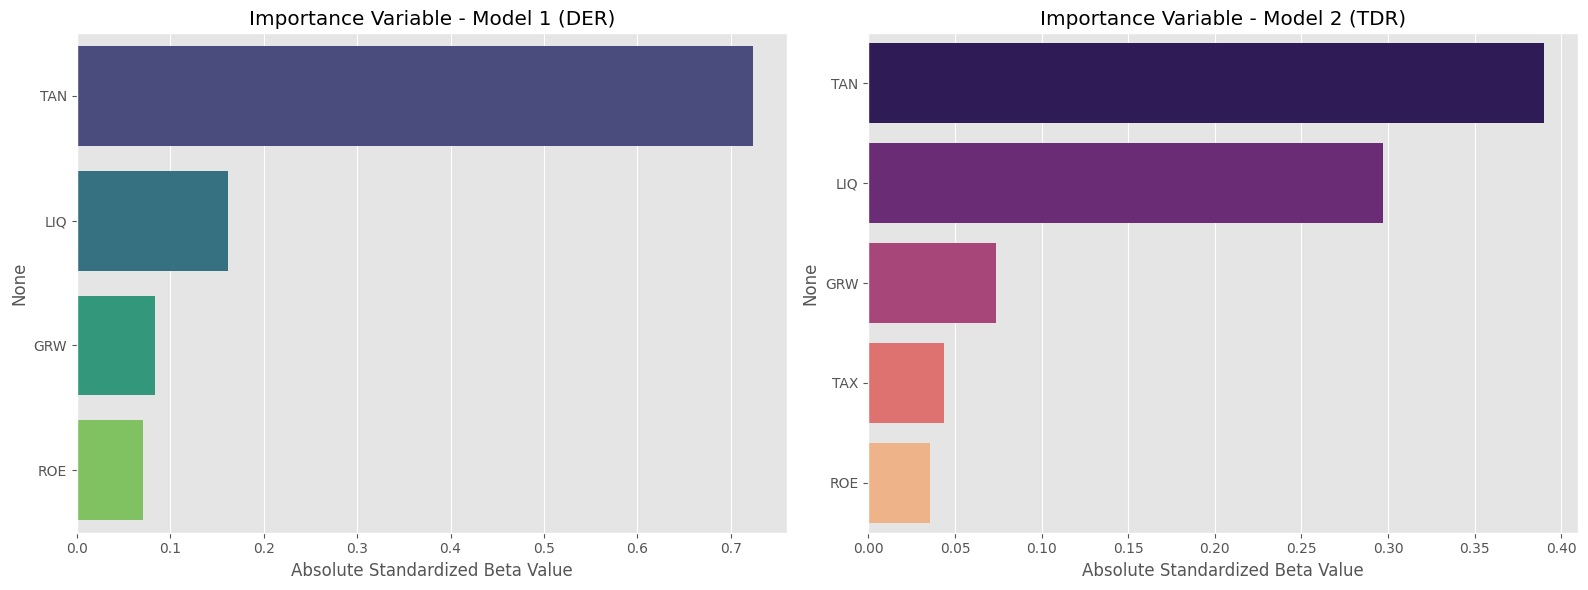

In [37]:
# Fix: Correct the indexing in the visualization cell as well
beta1_abs = standardized_beta1.loc[['ROE', 'TAN', 'LIQ', 'GRW']].dropna().abs().sort_values(ascending=False)
beta2_abs = standardized_beta2.loc[['ROE', 'TAN', 'LIQ', 'GRW', 'TAX']].dropna().abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model 1
sns.barplot(x=beta1_abs.values, y=beta1_abs.index, ax=axes[0], palette='viridis', hue=beta1_abs.index, legend=False)
axes[0].set_title('Importance Variable - Model 1 (DER)')
axes[0].set_xlabel('Absolute Standardized Beta Value')

# Plot Model 2
sns.barplot(x=beta2_abs.values, y=beta2_abs.index, ax=axes[1], palette='magma', hue=beta2_abs.index, legend=False)
axes[1].set_title('Importance Variable - Model 2 (TDR)')
axes[1].set_xlabel('Absolute Standardized Beta Value')

plt.tight_layout()
plt.show()

# Eksport dan Kesimpulan

In [38]:
model1_features = ['ROE', 'TAN', 'LIQ', 'GRW']
model2_features = ['ROE', 'TAN', 'LIQ', 'GRW', 'TAX']

# Ekspor ke format .pkl
joblib.dump(model1_features, '01_model1_features.pkl')
joblib.dump(model2_features, '01_model2_features.pkl')

print("Files exported: 01_model1_features.pkl, 01_model2_features.pkl")

Files exported: 01_model1_features.pkl, 01_model2_features.pkl


### 1. Penjelasan Variabel (Signifikansi dan Arah)
Model ini mengukur struktur modal melalui dua sudut pandang: **DER** (proporsi utang terhadap modal sendiri) pada Model 1, dan **TDR** (proporsi total utang terhadap total aset) pada Model 2.

Berikut adalah temuan untuk masing-masing variabel:
* **ROE (Profitabilitas): Signifikan, Arah Negatif.** Semakin tinggi laba, utang semakin turun.
* **LIQ (Likuiditas): Signifikan, Arah Negatif.** Semakin banyak uang kas, utang semakin turun.
* **GRW (Pertumbuhan): Signifikan, Arah Negatif.** Semakin pesat pertumbuhan aset, porsi utang semakin turun.
* **TAN (Struktur Aset Fisik): Signifikan, Arah Negatif.** Semakin besar kepemilikan aset fisik, utang semakin turun.
* **TAX (Beban Pajak): Signifikan, Arah Positif (Khusus TDR).** Semakin tinggi beban pajak, total utang justru semakin naik.

### 2. Interpretasi dan Analisis General
Secara keseluruhan, perusahaan properti dalam penelitian ini terbukti sangat rasional dan menjunjung tinggi prinsip kehati-hatian (*pecking order theory*). Saat kondisi perusahaan sedang prima, seperti laba tinggi, kas melimpah, dan aset kuat, mereka lebih memilih menggunakan dana internal untuk beroperasi daripada harus menarik utang baru.

Namun, ada satu pengecualian: **Pajak**. Ketika berhadapan dengan beban pajak yang tinggi, perusahaan merespons dengan cara sengaja menaikkan skala total utangnya (TDR). Ini adalah bentuk strategi pemanfaatan "Tameng Pajak" (*Tax Shield*), yang mana beban bunga utang dipakai sebagai pengurang penghasilan kena pajak demi menyelamatkan arus kas.

### 3. Analisis Faktor Paling Berpengaruh (Berdasarkan *Standardized Beta*)
Meskipun perusahaan menerapkan taktik tameng pajak, pengukuran kekuatan pengaruh (*standardized beta*) membuktikan bahwa **faktor fundamental internal jauh lebih mendominasi** dibandingkan sekadar urusan pajak.

* **Pada Model 1 (DER): Aset dan Kas adalah Jangkar Utama**
  Urutan kekuatan: **TAN > LIQ > GRW > ROE**.
  Dalam menekan rasio utang terhadap ekuitas, kepemilikan aset fisik (TAN) dan ketersediaan uang tunai (LIQ) adalah penentu paling utama. Perusahaan properti menyadari bahwa bisnis mereka padat modal, sehingga jaminan aset wujud dan likuiditas harian menjadi alasan paling mutlak untuk menahan diri dari utang luar.

* **Pada Model 2 (TDR): Fundamental Mengalahkan Taktik Pajak**
  Urutan kekuatan: **TAN > LIQ > GRW > TAX > ROE**.
  Ini adalah temuan yang paling krusial. Meskipun perusahaan terbukti secara sengaja menambah utang untuk menghindari pajak (TAX arahnya positif), kekuatan taktik pajak ini **masih kalah jauh** dibandingkan kekuatan aset (TAN), kas (LIQ), dan pertumbuhan (GRW).
  
  Artinya: Perusahaan memang menggunakan utang sebagai tameng pajak, **tetapi** mereka tidak akan melakukannya secara membabi buta. Keputusan menambah utang demi pajak hanya akan diambil jika kondisi aset fisik, ketersediaan uang kas, dan prospek pertumbuhan perusahaan sedang dalam posisi aman untuk menopang risiko utang tersebut.

***

**Kesimpulan Eksekutif:**
*"Penelitian ini membuktikan bahwa fundamental aset dan likuiditas adalah penentu tertinggi dalam keputusan struktur modal perusahaan properti. Perusahaan sangat memprioritaskan kemandirian finansial (pecking order theory) dengan menekan utang saat kondisi aset (TAN) dan kas (LIQ) sedang kuat. Sekalipun perusahaan terbukti memanfaatkan utang sebagai strategi tameng pajak (tax shield) saat beban pajak tinggi, taktik tersebut tetap menjadi prioritas sekunder yang pelaksanaannya sangat dibatasi oleh kekuatan fundamental internal perusahaan."*